In [1]:
import os
import sys
sys.path.insert(0, "..")

import io
import cv2
import json
import numpy as np
from PIL import Image
import gzip, shutil, os
from tqdm.auto import tqdm
from collections import Counter
from tfrecord.reader import tfrecord_loader


from src.constants import C2A_PALETTE, DATA_PATH
from src.utils import visualize_boxes

In [2]:
data_dir_path  = DATA_PATH / "raw" /  "android-in-the-wild" / "single"
assert  data_dir_path.exists()

In [3]:
sample_file = data_dir_path / "single-00001-of-00252"
out_file = data_dir_path / "single-00001-of-00252.tfrecord"

In [5]:
with gzip.open(sample_file, 'rb') as f_in, open(out_file, 'wb') as f_out:
    print(f_in)
    shutil.copyfileobj(f_in, f_out)

<gzip _io.BufferedReader name='/home/aliaagheis/master-study/sw/Click2Act/data/raw/android-in-the-wild/single/single-00001-of-00252' 0x7f4821a56290>


In [6]:
for i, record in enumerate(tfrecord_loader(out_file, index_path=None, description=None)):
    print(f"--- Record {i} ---")
    for k, v in record.items():
        if isinstance(v, bytes):
            print(f"  {k}: bytes, len={len(v)}")
        else:
            print(f"  {k}: shape={v.shape}, dtype={v.dtype}, value={v}")
    if i >= 2:
        break

--- Record 0 ---
  results/type_action: bytes, len=0
  results/yx_lift: shape=(2,), dtype=float32, value=[0.2319341  0.21882322]
  image/width: shape=(1,), dtype=int64, value=[720]
  step_id: shape=(1,), dtype=int64, value=[0]
  episode_length: shape=(1,), dtype=int64, value=[6]
  results/yx_touch: shape=(2,), dtype=float32, value=[0.2319341  0.21882322]
  results/action_type: shape=(1,), dtype=int64, value=[4]
  image/ui_annotations_positions: shape=(56,), dtype=float32, value=[0.04013158 0.87777776 0.03486842 0.04027778 0.11052632 0.33888888
 0.05065789 0.32222223 0.19473684 0.7513889  0.03223684 0.02916667
 0.19736843 0.87083334 0.02697368 0.03333334 0.19802631 0.09027778
 0.03026316 0.03888889 0.20526315 0.1625     0.01447368 0.14444445
 0.8855263  0.48055556 0.02565789 0.03333334 0.8881579  0.15972222
 0.02368421 0.05138889 0.91973686 0.125      0.01184211 0.125
 0.9203947  0.4513889  0.01052632 0.09583333 0.9203947  0.73333335
 0.01052632 0.15833333 0.95592105 0.48055556 0.028947

In [30]:
description = {                                                                                                                                             
    "goal_info"                      : "byte",                                                                                                            
    "episode_id"                     : "byte",                                                                                                              
    "episode_length"                 : "int",
    "step_id"                        : "int",                                                                                                               
    "device_type"                    : "byte",
    "android_api_level"              : "int",                                                                                                               
    "current_activity"               : "byte",
    "image/encoded"                  : "byte",                                                                                                              
    "image/height"                   : "int",                                                                                                               
    "image/width"                    : "int",
    "image/channels"                 : "int",                                                                                                               
    # "image/ui_annotations_text"      : "byte",
    # "image/ui_annotations_ui_types"  : "byte",                                                                                                              
    # "image/ui_annotations_positions" : "float",                                                                                                             
    "step_id"                        : "int",
    "device_type"                    : "byte",
    # "android_api_level"              : "int",
    "current_activity"               : "byte",
    "results/action_type"            : "int",
    "results/yx_touch"               : "float",
    "results/yx_lift"                : "float",
    "results/type_action"            : "byte",
}

In [40]:
imgs_arrays = []
goals =  []
results = []
for i, r in tqdm(enumerate(tfrecord_loader(str(sample_file), index_path=None,                                                                                    
                                        description=description, compression_type="gzip"))):
    # print(f"---- {i} ----")
    goals.append(r["goal_info"])
    results.append({
        "action_type": r["results/action_type"],
        "yx_touch": r["results/yx_touch"],
        "yx_lift": r["results/yx_lift"],
        "yx_lift": r["results/yx_lift"],
    })
    img_bytes = r["image/encoded"]
    h = int(r["image/height"][0])                                                                                                                          
    w = int(r["image/width"][0])
    c = int(r["image/channels"][0])
                                                                                                                                                                
    img_array = np.frombuffer(img_bytes, dtype=np.uint8).reshape((h, w, c))
    imgs_arrays.append(img_array)

0it [00:00, ?it/s]

In [41]:
imgs_arrays_np = np.array(imgs_arrays[:2])

In [42]:
distinct_img_arrays = [imgs_arrays[0]]
distinct_img_idxs = [0]

for i in range(1, len(imgs_arrays)):
    is_different = (distinct_img_arrays[-1] != imgs_arrays[i]).sum()
    if is_different:
        distinct_img_arrays.append(imgs_arrays[i])
        distinct_img_idxs.append(i)

In [43]:
len(distinct_img_idxs), len(imgs_arrays)

(247, 284)

In [45]:
goals

[b'go to google search bar and search & open ebay.com in chrome',
 b'go to google search bar and search & open ebay.com in chrome',
 b'go to google search bar and search & open ebay.com in chrome',
 b'go to google search bar and search & open ebay.com in chrome',
 b'go to google search bar and search & open ebay.com in chrome',
 b'go to google search bar and search & open ebay.com in chrome',
 b'Go to ebay search bar and search lg ultragear',
 b'Go to ebay search bar and search lg ultragear',
 b'Go to ebay search bar and search lg ultragear',
 b'Go to ebay search bar and search lg ultragear',
 b'Go to lg ultragear',
 b'Go to lg ultragear',
 b'Open first result and go to cart section, then Add to cart',
 b'Open first result and go to cart section, then Add to cart',
 b'Open first result and go to cart section, then Add to cart',
 b'Open first result and go to cart section, then Add to cart',
 b'Open first result and go to cart section, then Add to cart',
 b'Add to cart',
 b'Add to cart'

In [44]:
[r['yx_touch'] for  r in results]

[array([0.2319341 , 0.21882322], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.20090401, 0.33929187], dtype=float32),
 array([0.91623837, 0.47454444], dtype=float32),
 array([0.90828955, 0.82579595], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.18026462, 0.4402564 ], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.18290624, 0.92879766], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.18290624, 0.92879766], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.5197876, 0.5626715], dtype=float32),
 array([0.7209556, 0.6376008], dtype=float32),
 array([0.78785884, 0.5375971 ], dtype=float32),
 array([0.717458  , 0.52494097], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.717458  , 0.52494097], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.1334833, 0.3954829], dtype=float32),
 array([-1., -1.], dtype=float32),
 array([0.33068535, 0.20458479], dtype=float32),
 array([-1., -1.], dtype=float32),
 arra

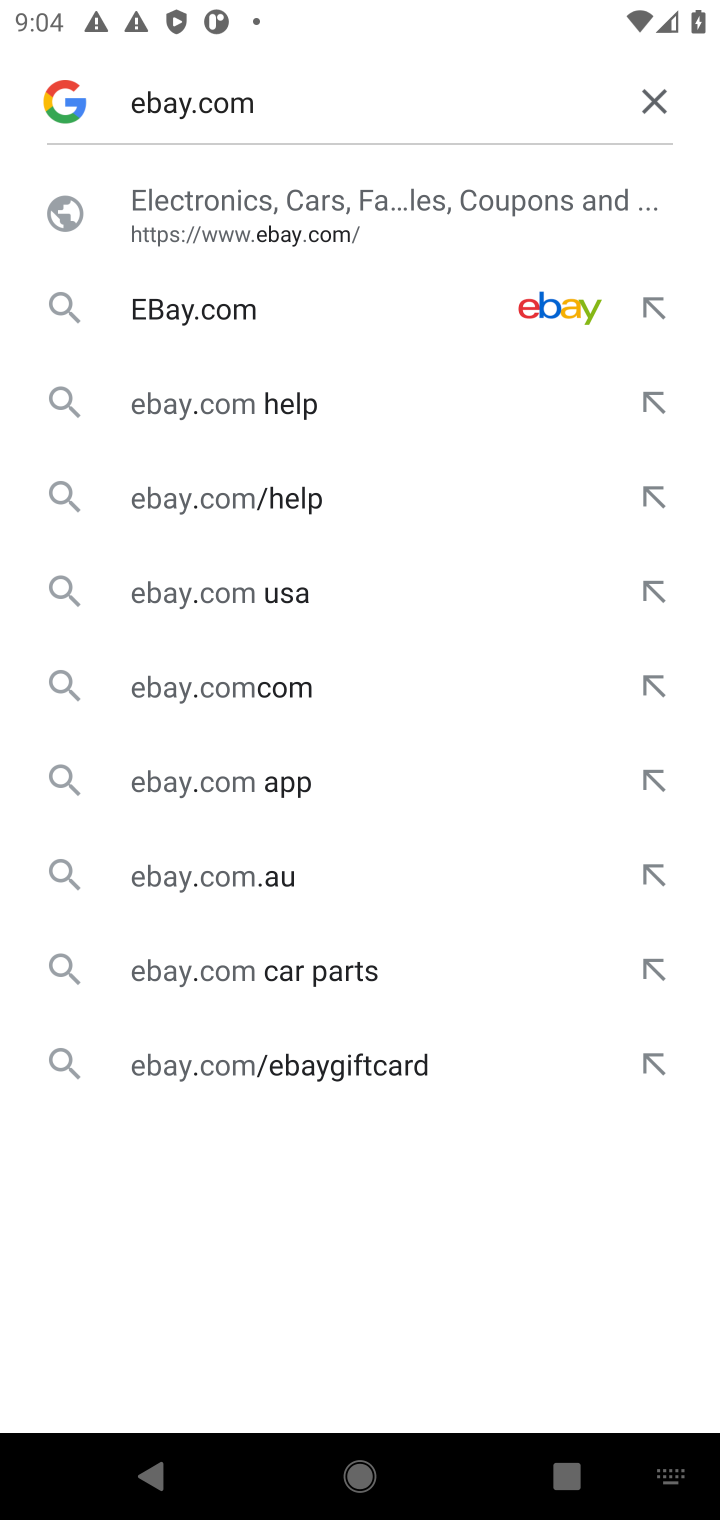

In [29]:
Image.fromarray(distinct_img_arrays[0])

In [ ]:
for i, record in enumerate(tfrecord_loader(str(sample_file), index_path=None,
                                             description=description,
                                             compression_type="gzip")):
    print(f"--- Record {i} ---")
    for k, v in record.items():
        print(f"  {k}: {v}")
    if i >= 2:
        break                                                                                                                                               
   